<a href="https://colab.research.google.com/github/Dipanjan-Chaudhuri/ED-and-VMC/blob/main/Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We are trying to estimate the ground state of the Hamiltonian;
$$ H = -J \sum_{i=0}^{N-2} \sigma_i^z \sigma_{i+1}^z - h \sum_{i=0}^{N-1} \sigma_i^x $$

Using **Exact Diagonalization** first and then compare it with **Neural Network and ML** results.

In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [3]:
# Pauli matrices for a single spin.
sx = np.array([[0,1],[1,0]], dtype = "complex")
sz = np.array([[1,0],[0,-1]], dtype = "complex")
I2 = np.eye(2, dtype="complex") # 2D Identity matrix

In [ ]:
def op_at_site(op,site,N):
    # Embed operator at required site to construct mb operator acting on that site.

    mats = [I2] * N  # All sites initialized with identity
    mats[site] = op   # Setting our operator at the required site.
    full = mats[0]    # iterative setup of tensor product using np.kron()

    for m in mats[1:]:
        full = np.kron(full,m)    # Creating the operator using tensor product over the entire lattice
    return full

In [ ]:
def hamiltonian(J,h,N):
    # Construct hamiltonian for the problem with parameters J,h and N

    H = np.zeros((2**N,2**N),dtype = "complex")   # Shell of our hamiltonian

    # Preparing the interaction term
    for i in range(0,N-1):
        H -= J * (op_at_site(sz,i,N) @ op_at_site(sz,i+1,N))

    # Preparing the field term
    for i in range(0,N):
        H -= h * (op_at_site(sx,i,N))

    return H
    # Our Hamiltonian is prepared !!

In [ ]:
# Now we shall diagonalize this Hamiltonian
H = hamiltonian(1,0.5,8)      # J = 1 , h = 0 , N = 8
H_diag = np.linalg.eigh(H)  # .eigh() because H is hermitian

E = H_diag.eigenvalues
V = H_diag.eigenvectors

N = 8
# Energy per site
E_per_site = E/N

E_0_site = np.min(E_per_site) # Ground state energy per site

In [ ]:
""" Now we shall vary h from 0 to 2J, this is important as this will allow us
to see the phase transition by tracking the order parameter, in this case m_z """

N,J = 8,1
h = np.linspace(0,2*J,41)

avg_sig = []
E_gap = []
''' Because of the symmetry of the ground state and the fact that the operator commutes
with the Hamiltonian, evaluating <sig_z> in the middle of the chain will always be zero.
 To avoid this problem, we measure the 2 point correlator at two points on the lattice
 <sig^{z}_i sig^{z}_j>'''

Sz_i = op_at_site(sz,1,N)
Sz_j = op_at_site(sz,N-2,N)

for i in h:
    H = hamiltonian(J,i,N)
    H_diag = np.linalg.eigh(H)

    E_0 = H_diag.eigenvalues[0]     # Ground state energy
    psi_0 = H_diag.eigenvectors[:,0]   # Ground state

    E_1 = H_diag.eigenvalues[1]   # 1st excited state, because first 2 states are degenerate.
    m_z = (psi_0.conj().T) @ (Sz_i @ Sz_j) @ (psi_0)

    avg_sig.append(m_z.real)
    E_gap.append(E_1 - E_0)

Text(0.5, 1.0, 'Variation of $m^z$ with field strength $h$')

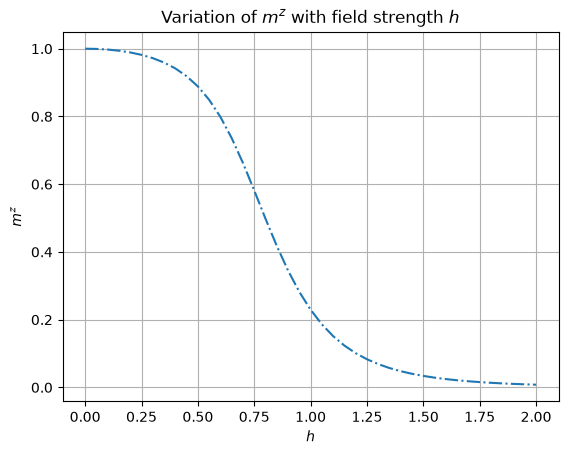

In [ ]:
plt.plot(h,avg_sig,"-.")
plt.xlabel(r"$h$")
plt.ylabel(r"$m^z$")
plt.grid()
plt.title(r"Variation of $m^z$ with field strength $h$")

Text(0.5, 1.0, 'Variation of $\\Delta E$ with field strength $h$')

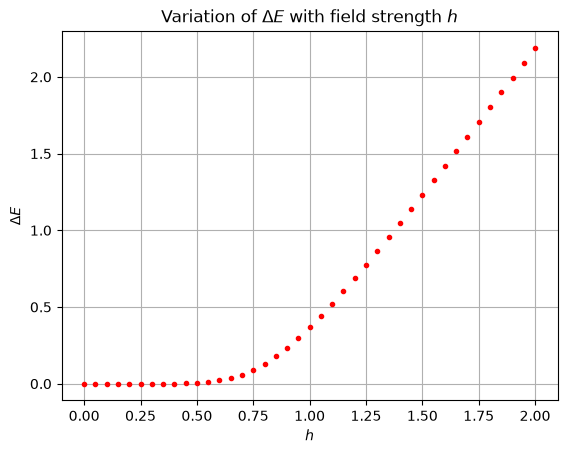

In [ ]:
# Energy gap variation with field strength

plt.plot(h,E_gap,". r")
plt.xlabel(r"$h$")
plt.ylabel(r"$\Delta E$")
plt.grid()
plt.title(r"Variation of $\Delta E$ with field strength $h$")

Now we apply Neural Networks to solve this exact problem, ref: Carleo & Troyer (2017). Instead of storing $\psi(s)$ as $2^N$ numbers, we represent it with a fixed number of small parameters $\theta$. We are using the **Restricted Boltzmann Machine (RBM)**. Ansatz -
$$\psi_\theta(s) = \sum_{\{h_j\}} \exp\left(\sum_i a_i s_i + \sum_{j} b_j h_j + \sum_{ij} W_ij s_i h_j\right)$$

$s \in \{+1,-1\}^N$ is the physical spin configuration (input). $\theta = (a_i,b_j,W_{ij})$

In [ ]:
# Setup of the system
N = 8
M = 8

# initializing theta
a = np.random.randn(N)*0.01 + 1j*np.random.randn(N)*0.01
b = np.random.randn(M)*0.01 + 1j*np.random.randn(M)*0.01
W = np.random.randn(N,M)*0.01 + 1j * np.random.randn(N,M)*0.01

In [ ]:
def log_psi(s,a,b,W):
    z = b + s @ W
    return ((a @ s) + np.sum(np.abs(z) + np.log(1 + np.exp(-2* np.abs(z)))))

In [ ]:
spin_configs = []
for i in range(2**N):
    s = np.array(list(bin(i)[2:].zfill(N)), dtype=int)

    for j in range(len(s)):
        if s[j] == 0:
            s[j] = -1

    spin_configs.append(s)

In [ ]:
def metropolis_sample(a,b,W,N,total_samples,burn_in,thin):
    s = np.random.choice([-1,1],size = N)
    samples = []
    n_accepted = 0   # Accepted samples
    for step in range(total_samples):
        site = np.random.choice(N)

        s_flipped = s.copy()
        s_flipped[site] = -s_flipped[site]

        r = 2 * (log_psi(s_flipped,a,b,W) - log_psi(s,a,b,W)).real

        u = np.random.uniform(0,1)

        if np.log(u) < r:
            s = s_flipped.copy()
            n_accepted += 1

        if step >= burn_in and (step - burn_in) % thin == 0:
            samples.append(s)

    n_samples = (total_samples - burn_in) // thin
    return np.reshape(samples,(n_samples,N))

In [ ]:
Psi_sqr_array = []
for s in spin_configs:
    log_Psi = log_psi(s,a,b,W)

    exponent = 2*(log_Psi.real)
    Psi_sqr_array.append(np.exp(exponent))

P_array = np.array(Psi_sqr_array)

#Normalization of the exact result we calculated
P_exact = P_array / P_array.sum()

total_samples = 100000
burn_in = 2000
thin = N

metro = metropolis_sample(a,b,W,N,total_samples,burn_in,thin)

n_samples = (total_samples - burn_in) // thin

# Preparing the result from the metropolis sampler
for i in range(n_samples):
    for j in range(N):
        if metro[i,j] == -1:
            metro[i,j] = 0

P_metro = np.zeros(n_samples, dtype=int)
for i in range(n_samples):
    x = metro[i,:]
    inte = int(x.dot(1 << np.arange(x.size)[::-1]))  # Binary to integer. Copied from Gemini :)
    P_metro[i] = inte

P_sampled = np.bincount(P_metro, minlength=256) / n_samples

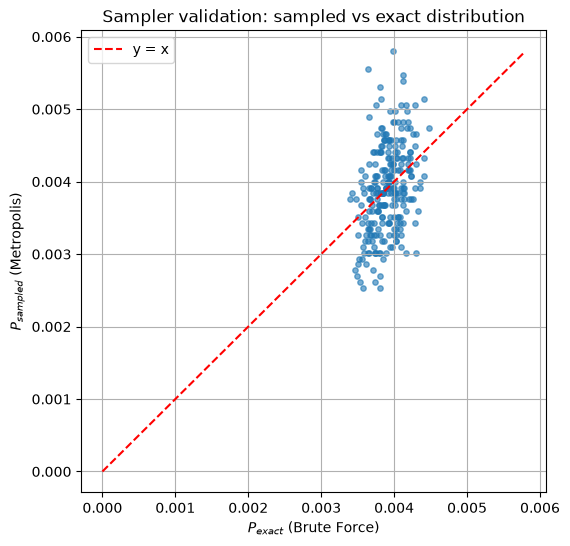

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(P_exact, P_sampled, alpha=0.6, s=15)

# reference diagonal y = x
lims = [0, max(P_exact.max(), P_sampled.max())]
plt.plot(lims, lims, 'r--', label='y = x')

plt.xlabel('$P_{exact}$ (Brute Force)')
plt.ylabel('$P_{sampled}$ (Metropolis)')
plt.title('Sampler validation: sampled vs exact distribution')
plt.grid()
plt.legend()

In [ ]:
def E_loc(s,a,b,W,J,h,N):
    # Interaction term
    I = -J * np.dot(s[:-1],s[1:])

    # Mean field term
    F = 0
    log_psi_s = log_psi(s,a,b,W)
    for i in range(N):
        s_flipped = s.copy()
        s_flipped[i] = -s_flipped[i]
        F -= h * np.exp(log_psi(s_flipped,a,b,W) - log_psi_s)
    E_local = I + F

    return E_local

In [ ]:
h = 0.5
E_local_metro = np.array([E_loc(s,a,b,W,J,h,N) for s in metro])
E_avg = np.mean(E_local_metro)

sd = np.mean(E_local_metro**2) - E_avg**2

std_error = sd/np.sqrt(n_samples)

E_site = E_avg/N

In [ ]:
print("Exact E_0/N = ",E_0_site)
print("NQS E_theta/N",E_site.real,"±", std_error.real)

Exact E_0/N =  -0.9550740691987598
NQS E_theta/N -0.7178343865284824 ± 0.01874265372485806


**The "Learning" part of Machine Learning:**

We now train the model we have to correctly estimate the ground state energy. We shall use **pytorch** to implement the ML algorithms.

In [ ]:
import torch as th

# Reinitialize the parameters using torch
# Requires_grad tells torch to focus on variations on this parameter.

a_t = (th.randn(N, dtype = th.cfloat) * 0.01).requires_grad_()
b_t = (th.randn(M, dtype = th.cfloat) * 0.01).requires_grad_()
W_t= (th.randn(N, M, dtype = th.cfloat) * 0.01).requires_grad_()

In [ ]:
def Log_psi(s,a_t,b_t,W_t):
    z = b_t + s @ W_t
    return s @ a_t + th.sum(abs(z) + th.log(1 + th.exp(-2 * abs(z))), dim = -1)

In [ ]:
# Testing the code
s_test = th.tensor([1.,-1.,-1.,1.,1.,-1.,1.,-1.], dtype=th.cfloat)
res = Log_psi(s_test,a_t,b_t,W_t)
res.real.backward()        # Backpropagating through the Log_psi() function, essentially constructing an operation using partial derivatives in a sequence.

In [ ]:
def surrogate_loss(metro, E_local_metro, a, b, W):
    # 'loss' does not mean we are losing information.
    #  It is used here because it represents error. Which should eventually go to zero

    s_batch = metro.to(th.cfloat)                     # This is the way we transform a numpy.ndarray to Tensor
    weights = (E_local_metro - E_avg).to(th.cfloat)

    return 2 * th.mean( weights * th.conj(Log_psi(s_batch, a, b, W))).real

In [ ]:
L = surrogate_loss(th.from_numpy(metro), th.from_numpy(E_local_metro), a_t, b_t, W_t)
L

tensor(-0.0053, grad_fn=<MulBackward0>)

In [ ]:
L.backward()
print(a_t.grad.real)

tensor([ 0.7420, -1.5168, -1.4849,  0.5012,  0.4871, -1.4887,  0.5014, -1.2505])


In [ ]:
# Setting up the loop
total_samples = 100000
burn_in = 2000
thin = N
J,h = 1, 0.5

a_t = (th.randn(N, dtype = th.cfloat) * 0.01).requires_grad_()
b_t = (th.randn(M, dtype = th.cfloat) * 0.01).requires_grad_()
W_t = (th.randn(N, M, dtype = th.cfloat) * 0.01).requires_grad_()

optimizer  = th.optim.Adam([a_t,b_t,W_t], lr = 0.01)
iterations = 300

E_per_site_learned = []

In [ ]:
for iteration in range(iterations):
    met = metropolis_sample(a_t.detach().numpy(), b_t.detach().numpy(), W_t.detach().numpy(), N, total_samples, burn_in, thin)
    E_local = np.array([E_loc(s,a_t.detach().numpy(),b_t.detach().numpy(), W_t.detach().numpy(),J,h,N) for s in met])

    E_mean = np.mean(E_local)
    E_per_site_learned.append(E_mean.real/N)  # This should tend to the exact value of E_0/N

    optimizer.zero_grad()

    L = surrogate_loss(th.from_numpy(met), th.from_numpy(E_local),a_t, b_t, W_t)

    back = L.backward()

    optimizer.step()

    if iteration % 20 == 0:
        print("Step = ",iteration, "; Energy value = ", E_per_site_learned[-1])
    elif iteration == (iterations - 1):
        print("Code Executed")

Step =  0 ; Energy value =  -0.5016016323944352
Step =  20 ; Energy value =  -0.5192080591229157
Step =  40 ; Energy value =  -0.8827100427711109
Step =  60 ; Energy value =  -0.8750078003815015
Step =  80 ; Energy value =  -0.8750000634952766
Step =  100 ; Energy value =  -0.8750000000813436
Step =  120 ; Energy value =  -0.875000000001372
Step =  140 ; Energy value =  -0.8750000000000027
Step =  160 ; Energy value =  -0.875
Step =  180 ; Energy value =  -0.875
Step =  200 ; Energy value =  -0.875
Step =  220 ; Energy value =  -0.875
Step =  240 ; Energy value =  -0.875
Step =  260 ; Energy value =  -0.875
Step =  280 ; Energy value =  -0.875
Code Executed


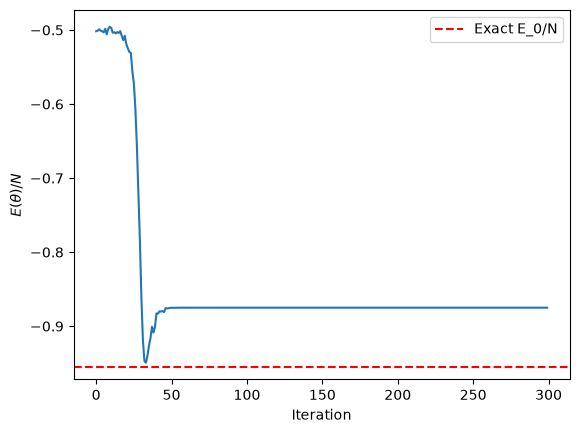

In [ ]:
plt.plot(E_per_site_learned)
plt.axhline(E_0_site,linestyle = "--", color = "r" , label = "Exact E_0/N")
plt.xlabel('Iteration')
plt.ylabel(r'$E(\theta)/N$')
plt.legend()

In [ ]:
s_test = met[0]
print(E_loc(s_test, a_t.detach().numpy(),b_t.detach().numpy(), W_t.detach().numpy(), J=1, h=0.0, N=8))
print(E_loc(s_test, a_t.detach().numpy(),b_t.detach().numpy(), W_t.detach().numpy(), J=1, h=0.5, N=8))

(-7+0j)
(-7+1.3624102978758427e-31j)
